## Latency Metrics

In [1]:
from experiment_analysis import load_experiment_latencies

# Load experiment 3 from ./experiments/3
df = load_experiment_latencies(exp_id=1)

df.head()
df.describe(percentiles=[0.5, 0.9, 0.99])[[
    "end_to_end_s",
    "server_roundtrip_s",
    "router_queue_s",
    "vllm_compute_s",
]]


,end_to_end_s,server_roundtrip_s,router_queue_s,vllm_compute_s
count,200.000000,200.000000,200.000000,200.000000
mean,57.795467,56.181367,25.247258,25.497478
std,23.565479,22.952920,21.505428,23.440518
min,11.520083,11.103379,0.048732,0.491463
50%,61.875985,59.775285,24.027480,18.032927
90%,84.396536,82.213598,56.068665,62.693310
99%,112.464290,109.601380,64.114528,96.593244
max,119.024286,116.272725,64.920739,103.313918


In [2]:
df

,idx,req_id,send_failed,end_to_end_s,model_latency_s,finish_reason,prompt_tokens,completion_tokens,total_tokens,serving_pod,...,applied_time_offset_s,client_to_router_s,router_queue_s,router_to_sidecar_s,sidecar_queue_s,vllm_compute_s,sidecar_post_s,sidecar_to_router_s,router_post_result_s,server_roundtrip_s
0,36,98c124a6afae45a390cd8ca919f1c8ff,False,11.520083,11.066161,stop,381,3,384,None,...,NaN,0.416704,0.433301,0.015895,0.000116,11.067440,0.000092,0.002458,0.000765,11.103379
1,12,d088e191fdcc4c69ad5d1e13b5cb8643,False,11.842530,11.608371,stop,319,3,322,None,...,NaN,0.177175,0.211616,0.016350,0.000990,11.609356,0.000055,0.003003,0.001142,11.665354
2,7,82c1ff2cd40e4a8f9ba97da68b4bd7fb,False,11.903915,11.638632,stop,457,4,461,None,...,NaN,0.085120,0.230718,0.016350,0.014168,11.639703,0.000048,0.002461,0.000406,11.818795
3,4,31cd5d2f81ed418d9f0e41607fecda7c,False,14.100425,13.847667,stop,450,3,453,None,...,NaN,0.112029,0.228019,0.015296,0.000104,13.849318,0.000053,0.007111,0.000510,13.988396
4,33,9fd355c57efe46a78bf9cf4742e14718,False,14.043286,13.596580,stop,297,3,300,None,...,NaN,0.404413,0.422870,0.015266,0.000103,13.598464,0.000065,0.004795,0.001712,13.638873
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,38,c73683fb920b462783383d011ea1c5c6,False,103.935939,103.312795,length,413,2048,2461,None,...,NaN,0.464399,0.590321,0.015841,0.011887,103.313918,0.000147,0.003269,0.000547,103.471540
196,142,4cdd4cea7d2b43bdbe985033db58c39b,False,104.593334,42.861517,stop,276,1482,1758,None,...,NaN,3.253358,61.726610,0.000676,0.000038,42.862381,0.000082,0.003091,0.000450,101.339975
197,119,5a2f0cfd42c643dd9ac5131f3671781a,False,112.447543,57.699725,stop,380,1887,2267,None,...,NaN,2.863583,54.741109,0.000721,0.000050,57.700992,0.000177,0.003970,0.000518,109.583960
198,137,925121e7ea7044cd9d7862b0bfeef1ba,False,114.122233,62.404224,length,382,2048,2430,None,...,NaN,2.796322,51.712594,0.000625,0.000039,62.405280,0.000127,0.003056,0.000505,111.325910


In [3]:
from experiment_analysis import experiments_from_series, experiments_from_series

In [4]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import pandas as pd

# ---- choose experiments ----
# Option A: by series IDs
# series_ids = [53]
# experiments = experiments_from_series(series_ids)

# Option B: by start/end range
experiments = list(range(241, 254))

print(experiments)

# ----------------------------------------------
# Latency columns of interest
cols = [
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]
percentiles = [0.5, 0.9, 0.99]
summaries = []
for exp_id in experiments:
    df = load_experiment_latencies(exp_id=exp_id)
    summary = (
        df.describe(percentiles=percentiles)[cols]
          .add_prefix(f"exp{exp_id}_")
    )
    summaries.append(summary)
# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)
comparison

[241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253]


,exp241_end_to_end_s,exp242_end_to_end_s,exp243_end_to_end_s,exp244_end_to_end_s,exp245_end_to_end_s,exp246_end_to_end_s,exp247_end_to_end_s,exp248_end_to_end_s,exp249_end_to_end_s,exp250_end_to_end_s,exp251_end_to_end_s,exp252_end_to_end_s,exp253_end_to_end_s
count,9998.000000,9998.000000,9998.000000,9997.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,25.754409,85.068395,57.090423,69.217397,78.900759,30.532832,131.031548,125.477010,85.343260,99.241343,130.333131,134.515987,142.101506
std,41.937398,81.809824,69.199512,69.063828,114.052194,43.817929,144.787869,80.635222,101.179670,90.796231,118.139806,136.585632,132.755937
min,0.243837,0.329869,0.185705,0.177514,0.212083,0.191632,0.220254,0.538638,0.211029,0.268428,0.370112,0.389641,0.278171
50%,14.213755,58.884533,33.386510,47.764500,37.316924,19.461258,75.452173,125.521331,51.522761,74.622174,90.565338,82.331777,93.301430
90%,53.402251,201.225989,144.986881,166.326770,210.805526,62.466654,356.015733,216.331375,197.158543,223.827025,291.758803,333.752714,335.487578
99%,299.744682,353.270234,319.896609,324.551060,609.887302,278.994307,573.232925,401.812986,470.377671,377.057773,475.754615,527.716749,484.043185
max,375.509369,605.659792,573.309158,576.867251,940.216805,450.912673,880.078770,680.036851,807.179929,736.804274,710.835341,926.192317,820.740997


[241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253]
[exp 241] corrected_requests=9998/9998
[exp 242] corrected_requests=9998/9998
[exp 243] corrected_requests=9998/9998
[exp 244] corrected_requests=9997/9997
[exp 245] corrected_requests=0/10000
[exp 246] corrected_requests=0/10000
[exp 247] corrected_requests=0/10000
[exp 248] corrected_requests=0/10000
[exp 249] corrected_requests=0/10000
[exp 250] corrected_requests=0/10000
[exp 251] corrected_requests=0/10000
[exp 252] corrected_requests=0/10000
[exp 253] corrected_requests=0/10000

Average latencies per experiment:

[time_offsets] APPLY_TIME_OFFSETS=True

Experiment 241:
  client_to_router_s          : -836.029 s
  router_queue_s              : -834.236 s
  router_to_sidecar_s         :  835.903 s
  sidecar_queue_s             :    0.004 s
  vllm_compute_s              :   23.905 s
  sidecar_post_s              :    0.000 s
  sidecar_to_router_s         : -835.894 s
  router_post_result_s        :      nan s
  SUM (co

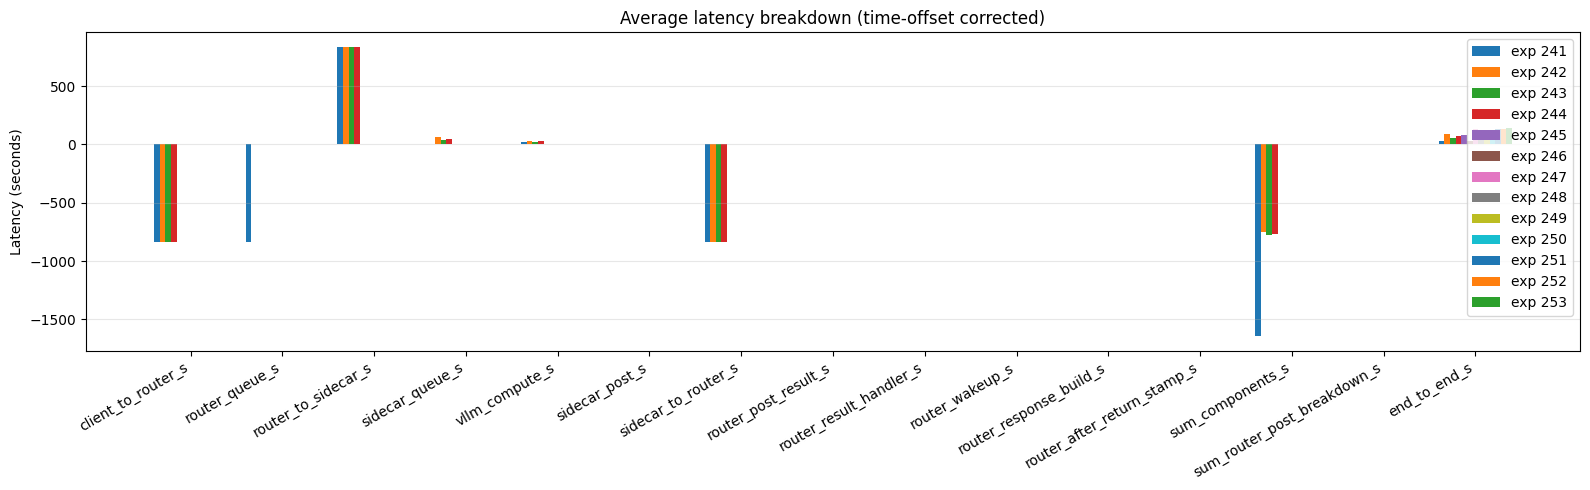

In [5]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt
import numpy as np

# ---- choose experiments ----
# Option A: by series IDs
# series_ids = [53]
# experiments = experiments_from_series(series_ids)

# Option B: by start/end range
experiments = list(range(241, 254))

print(experiments)
# ---------------------------
# ============================================================
# TIME CORRECTION FLAG (NEW)
# ============================================================
APPLY_TIME_OFFSETS = True   # <- set False to revert to old behavior
# ============================================================
# Non-overlapping latency components (base)
component_cols = [
    "client_to_router_s",
    "router_queue_s",
    "router_to_sidecar_s",
    "sidecar_queue_s",
    "vllm_compute_s",
    "sidecar_post_s",
    "sidecar_to_router_s",
    "router_post_result_s",
]
# router post-result breakdown (should sum ~ router_post_result_s when present)
router_post_breakdown_cols = [
    "router_result_handler_s",     # time spent inside /result handler (very small normally)
    "router_wakeup_s",             # waiter unblocked -> wait_for_result returns
    "router_response_build_s",     # build/merge trace/rename fields
    "router_after_return_stamp_s", # any last stamp after response object prepared (if you keep it)
]
extra_component_cols = [
    # keep empty unless you explicitly expose more metrics columns
]
e2e_col = "end_to_end_s"
plot_cols = (
    component_cols
    + router_post_breakdown_cols
    + extra_component_cols
    + ["sum_components_s", "sum_router_post_breakdown_s", e2e_col]
)
avg_by_exp = {}
for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
        apply_time_offset_correction=APPLY_TIME_OFFSETS,
    )
    # (optional) sanity: how many requests actually got corrected?
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")
    # Base component means
    comp_means = df.reindex(columns=component_cols).mean(numeric_only=True)
    sum_components = float(comp_means.sum(skipna=True))
    # Router post breakdown means
    post_means = df.reindex(columns=router_post_breakdown_cols).mean(numeric_only=True)
    sum_post_breakdown = float(post_means.sum(skipna=True))
    # Optional extras
    extra_means = df.reindex(columns=extra_component_cols).mean(numeric_only=True)
    e2e_mean = float(df[e2e_col].mean()) if e2e_col in df.columns else float("nan")
    row = {}
    for k in component_cols:
        row[k] = float(comp_means.get(k, np.nan))
    for k in router_post_breakdown_cols:
        row[k] = float(post_means.get(k, np.nan))
    for k in extra_component_cols:
        row[k] = float(extra_means.get(k, np.nan))
    row["sum_components_s"] = sum_components
    row["sum_router_post_breakdown_s"] = sum_post_breakdown
    row[e2e_col] = e2e_mean
    avg_by_exp[exp_id] = row
# ---- print numbers ----
print("\nAverage latencies per experiment:\n")
print(f"[time_offsets] APPLY_TIME_OFFSETS={APPLY_TIME_OFFSETS}\n")
for exp_id in experiments:
    r = avg_by_exp[exp_id]
    print(f"Experiment {exp_id}:")
    for k in component_cols:
        print(f"  {k:28s}: {r[k]:8.3f} s")
    print(f"  {'SUM (components)':28s}: {r['sum_components_s']:8.3f} s")
    print()
    print("  Router post-result breakdown:")
    for k in router_post_breakdown_cols:
        print(f"    {k:26s}: {r[k]:8.6f} s")
    print(f"    {'SUM (post breakdown)':26s}: {r['sum_router_post_breakdown_s']:8.6f} s")
    base_post = r.get("router_post_result_s", np.nan)
    if not (np.isnan(base_post) or np.isnan(r["sum_router_post_breakdown_s"])):
        diff = base_post - r["sum_router_post_breakdown_s"]
        print(f"    {'router_post_result_s':26s}: {base_post:8.6f} s")
        print(f"    {'DIFF (base - sum)':26s}: {diff:8.6f} s")
    print()
    print(f"  {e2e_col:28s}: {r[e2e_col]:8.3f} s")
    print()
# ---- grouped bar plot ----
labels = plot_cols
x = np.arange(len(labels))
width = 0.8 / max(1, len(experiments))
plt.figure(figsize=(16, 5))
for i, exp_id in enumerate(experiments):
    vals = [avg_by_exp[exp_id].get(k, np.nan) for k in labels]
    plt.bar(x + i * width, vals, width, label=f"exp {exp_id}")
plt.xticks(
    x + width * (len(experiments) - 1) / 2,
    labels,
    rotation=30,
    ha="right"
)
plt.ylabel("Latency (seconds)")
plt.title(
    "Average latency breakdown (time-offset corrected)"
    if APPLY_TIME_OFFSETS
    else "Average latency breakdown (raw clocks)"
)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

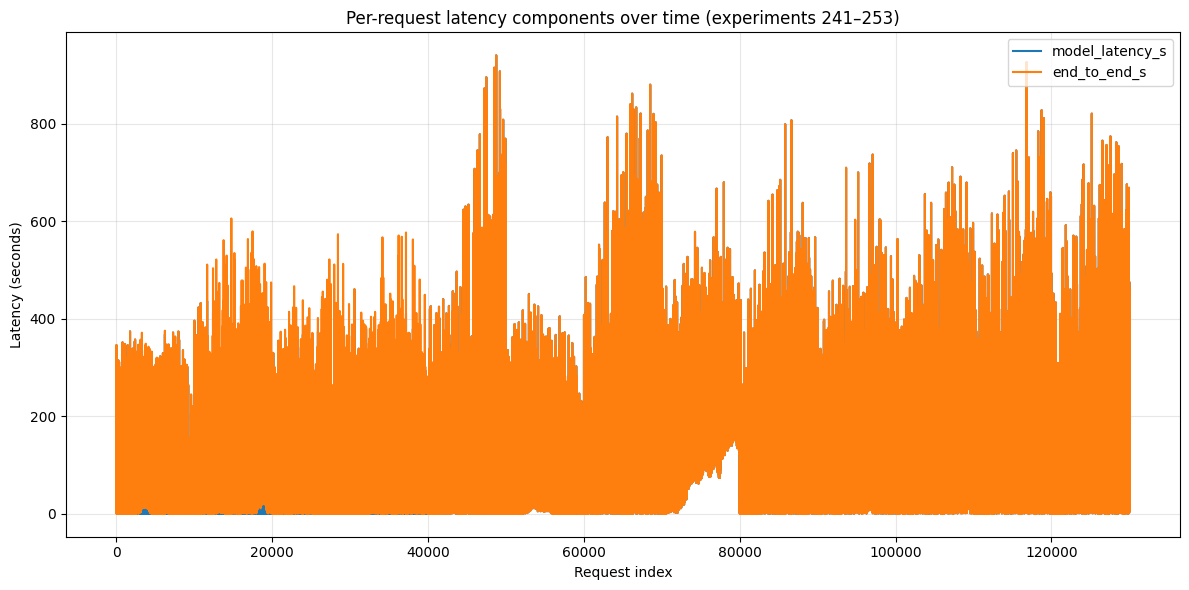

In [6]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt

# ---- choose experiment ----
# Option A: single experiment
# exp_id = 1

# Option B: by start/end range
experiments = list(range(241, 254))
# ---------------------------

import pandas as pd

dfs = []
for exp_id in experiments:
    _df = load_experiment_latencies(exp_id=exp_id).sort_values("idx").reset_index(drop=True)
    _df["exp_id"] = exp_id
    dfs.append(_df)
df = pd.concat(dfs, ignore_index=True)

# X-axis: request index (0, 1, 2, ...)
x = df.index

# Latency metrics to plot over time
latency_cols = [
    "model_latency_s",
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "router_to_sidecar_s",
    # "sidecar_queue_s",
    # "vllm_compute_s",
]
plt.figure(figsize=(12, 6))
for col in latency_cols:
    if col in df.columns:
        plt.plot(x, df[col], label=col)
plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(f"Per-request latency components over time (experiments {experiments[0]}–{experiments[-1]})")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

[226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238]
[exp 226] corrected_requests=9998/9998
[exp 227] corrected_requests=9997/9997
[exp 228] corrected_requests=10000/10000
[exp 229] corrected_requests=10000/10000
[exp 230] corrected_requests=0/7991
[exp 231] corrected_requests=0/8315
[exp 232] corrected_requests=0/7927
[exp 233] corrected_requests=0/8094
[exp 234] corrected_requests=0/8176
[exp 235] corrected_requests=0/7517
[exp 236] corrected_requests=0/7622
[exp 237] corrected_requests=0/8084
[exp 238] corrected_requests=0/8422


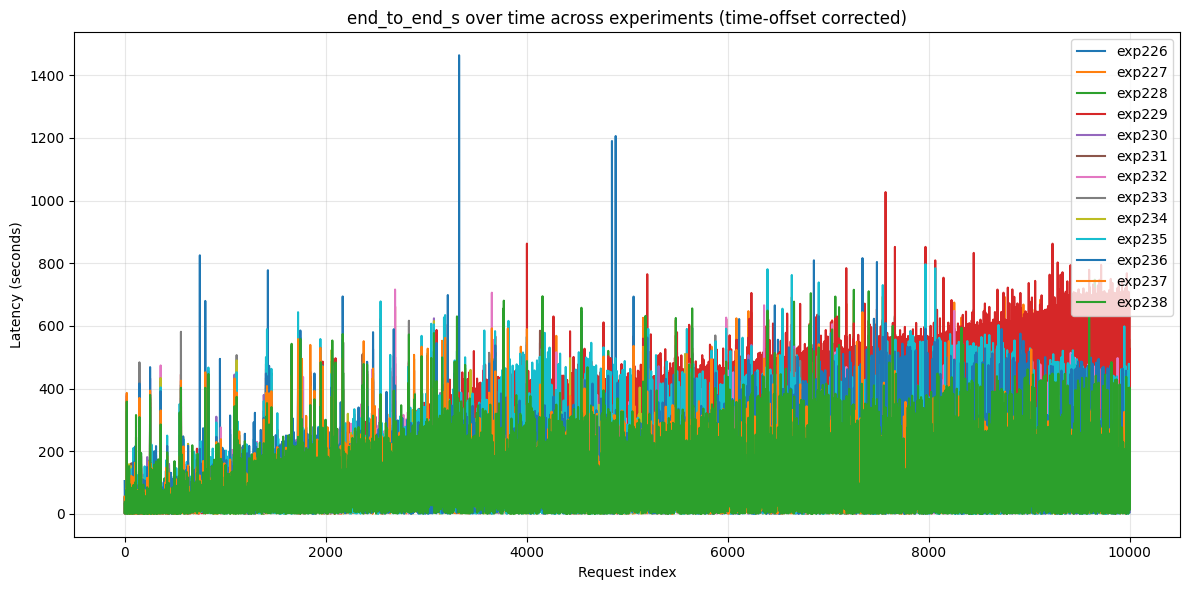

In [7]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt

# ---- choose experiments ----
# Option A: by series IDs
# series_ids = [53]
# experiments = experiments_from_series(series_ids)

# Option B: by start/end range
experiments = list(range(226, 239))

# experiments = [142]
print(experiments)
# ----------------------------
# ============================================================
# TIME CORRECTION FLAG (NEW)
# ============================================================
APPLY_TIME_OFFSETS = True   # <- set False to revert to old behavior
# ============================================================
# ---- choose ONE metric (uncomment exactly one) ----
metric = "end_to_end_s"          # total client → router → server → client
# metric = "server_roundtrip_s"  # router → vLLM → router
# metric = "router_queue_s"      # waiting time in router queue
# metric = "router_to_sidecar_s" # router → sidecar hop
#metric = "sidecar_queue_s"     # waiting time inside sidecar
# metric = "vllm_compute_s"      # actual model compute time
# metric = "router_post_result_s"
# -----------------------------------------------
plt.figure(figsize=(12, 6))
for exp_id in experiments:
    df = (
        load_experiment_latencies(
            exp_id=exp_id,
            apply_time_offset_correction=APPLY_TIME_OFFSETS,
        )
        .sort_values("idx")
        .reset_index(drop=True)
    )
    # (optional) sanity: how many requests actually got corrected?
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")
    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue
    x = df["idx"]
    y = df[metric]
    plt.plot(x, y, label=f"exp{exp_id}")
plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(
    f"{metric} over time across experiments "
    + ("(time-offset corrected)" if APPLY_TIME_OFFSETS else "(raw clocks)")
)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Throughput Metrics

In [8]:
from experiment_analysis import load_experiment_prom_samples, experiments_from_series
import pandas as pd

# -------- choose experiments to compare --------
# Option A: by series IDs
# series_ids = [53]
# experiments = experiments_from_series(series_ids)

# Option B: by start/end range
experiments = list(range(241, 254))

print(experiments)
# ----------------------------------------------
# Prometheus metric columns of interest
# (these are the fields inside each "samples" object in metrics.jsonl)
cols = [
    "gen_tokens_per_sec",
    "prefill_tokens_per_sec",
    "requests_running",
    # "requests_waiting",
    # "request_success_per_sec",
    # "request_failure_per_sec",
    # "preemptions_per_sec",
    # "gpu_kv_cache_usage_frac",
    # "cpu_kv_cache_usage_frac",
    #
    # vLLM latency hist averages (if your vLLM exposes them)
    "ttft_seconds_avg",
    "tpot_seconds_avg",
    # "e2e_latency_seconds_avg",
    # "queue_time_seconds_avg",
    # "inference_time_seconds_avg",
    # "prefill_time_seconds_avg",
    # "decode_time_seconds_avg",
    #
    # token distribution hists (averages)
    # "request_prompt_tokens_avg",
    # "request_generation_tokens_avg",
    # "request_max_generation_tokens_avg",
    #
    # spec decode (optional)
    # "spec_tokens_accepted_per_sec",
    # "spec_tokens_draft_per_sec",
    # "spec_tokens_emitted_per_sec",
]
percentiles = [0.5, 0.9, 0.99]
summaries = []
for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)
    if prom.empty:
        print(f"[WARN] exp{exp_id}: no prom metrics found (metrics.jsonl missing/empty)")
        continue
    # Option 1 (simple): pool all instances together, treat each (tick,instance) as a sample
    # Option 2 (cluster view): sum across instances per tick, then describe the per-tick totals
    # Choose one; default below is cluster view because it's usually what you want when comparing runs.
    # ---- CLUSTER VIEW (recommended): sum across instances per tick ----
    # keeps time granularity, avoids overweighting runs with more instances in the file
    agg = prom.groupby("ts")[cols].sum(min_count=1).reset_index()
    # Describe only selected cols
    summary = (
        agg[cols]
        .describe(percentiles=percentiles)
        .add_prefix(f"exp{exp_id}_")
    )
    summaries.append(summary)
# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)
comparison

[241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253]


,exp241_gen_tokens_per_sec,exp241_prefill_tokens_per_sec,exp241_requests_running,exp241_ttft_seconds_avg,exp241_tpot_seconds_avg,exp242_gen_tokens_per_sec,exp242_prefill_tokens_per_sec,exp242_requests_running,exp242_ttft_seconds_avg,exp242_tpot_seconds_avg,...,exp252_gen_tokens_per_sec,exp252_prefill_tokens_per_sec,exp252_requests_running,exp252_ttft_seconds_avg,exp252_tpot_seconds_avg,exp253_gen_tokens_per_sec,exp253_prefill_tokens_per_sec,exp253_requests_running,exp253_ttft_seconds_avg,exp253_tpot_seconds_avg
count,449.000000,449.000000,449.000000,410.000000,448.000000,499.000000,499.000000,499.000000,470.000000,498.000000,...,581.000000,581.000000,581.000000,567.000000,580.000000,585.000000,585.000000,585.000000,543.000000,585.000000
mean,2697.937633,382.127422,101.979955,19.957115,0.598258,2433.487895,345.580845,99.801603,19.418133,0.628700,...,2276.591900,322.861070,96.592083,1559.875742,0.657678,2259.777313,319.691904,94.664957,1713.974806,0.625016
std,800.182692,134.517571,32.313297,5.147570,0.141558,871.586173,138.099665,36.725875,6.590408,0.207673,...,870.296357,131.938647,36.893143,824.476639,0.432410,856.346343,135.351114,36.093873,860.393474,0.224481
min,0.000000,0.000000,0.000000,6.816158,0.048402,0.000000,0.000000,0.000000,1.010002,0.019449,...,0.000000,0.000000,0.000000,8.289205,0.050277,0.000000,0.000000,0.000000,10.130346,0.023938
50%,2928.521022,415.729992,113.000000,19.175124,0.627400,2740.620690,390.117175,116.000000,19.473590,0.681963,...,2629.844316,366.752463,114.000000,1795.537839,0.696238,2581.774454,355.894089,112.000000,1842.197429,0.684187
90%,3270.886376,489.309417,124.000000,26.160596,0.692475,3108.088266,459.290047,123.000000,26.242116,0.780268,...,2998.689655,438.448276,122.000000,2573.361654,0.836627,2989.489163,452.600000,120.000000,2751.928777,0.809900
99%,3546.603350,568.793817,126.000000,36.393839,0.773210,3299.097344,520.313750,125.000000,37.880628,0.885034,...,3194.041379,502.432079,125.000000,2731.357771,1.045194,3185.524138,526.387586,124.000000,2894.509267,1.004272
max,3670.513136,618.080829,128.000000,43.753638,1.375783,3436.689655,570.911867,126.000000,51.565504,1.627240,...,3292.931034,561.384236,127.000000,2796.196480,7.134993,3333.137931,550.322366,126.000000,2925.567631,1.407658


[241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253]


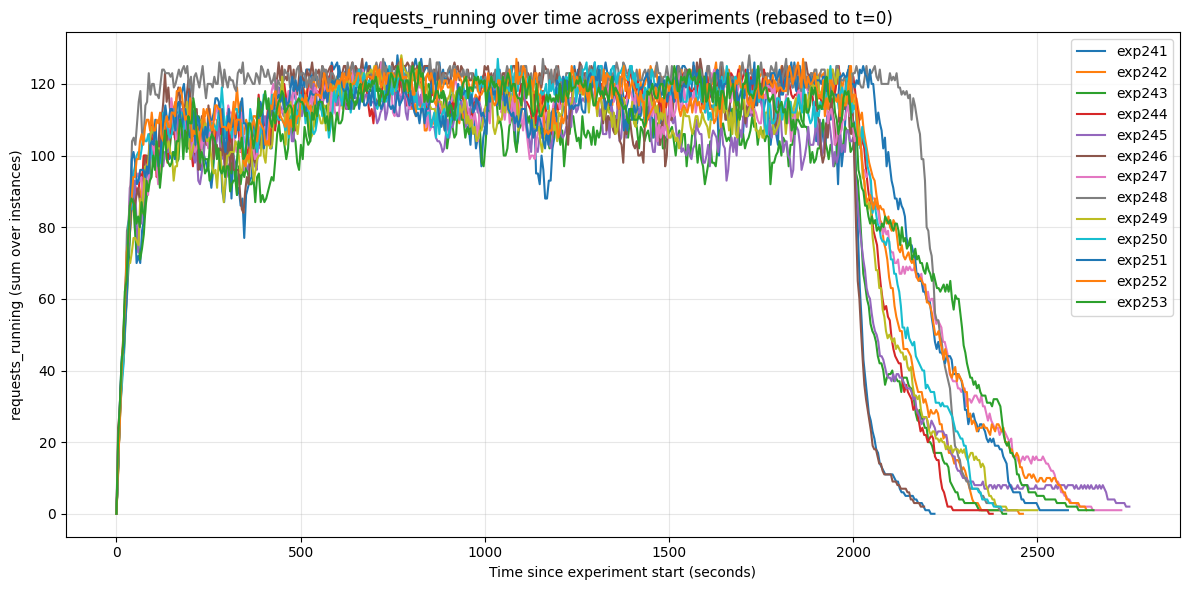

In [9]:
from experiment_analysis import load_experiment_prom_samples, experiments_from_series
import matplotlib.pyplot as plt

# ---- choose experiments ----
# Option A: by series IDs
# series_ids = [53]
# experiments = experiments_from_series(series_ids)

# Option B: by start/end range
experiments = list(range(241, 254))

print(experiments)
# ----------------------------
# ---- choose ONE metric (uncomment exactly one) ----
metric = "requests_running"
# metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "request_success_per_sec"
# metric = "request_failure_per_sec"
# metric = "preemptions_per_sec"
# metric = "gpu_kv_cache_usage_frac"
# metric = "cpu_kv_cache_usage_frac"
# metric = "requests_waiting"
# metric = "ttft_seconds_avg"
# metric = "tpot_seconds_avg"
# metric = "e2e_latency_seconds_avg"
# metric = "queue_time_seconds_avg"
# metric = "inference_time_seconds_avg"
# metric = "prefill_time_seconds_avg"
# metric = "decode_time_seconds_avg"
# metric = "request_prompt_tokens_avg"
# metric = "request_generation_tokens_avg"
# metric = "request_max_generation_tokens_avg"
# metric = "spec_tokens_accepted_per_sec"
# metric = "spec_tokens_draft_per_sec"
# metric = "spec_tokens_emitted_per_sec"
# -----------------------------------------------
# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"   # cluster-level
# agg_mode = "mean"  # per-instance average
# -----------------------------------------------
plt.figure(figsize=(12, 6))
for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)
    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue
    prom = prom.sort_values("ts").reset_index(drop=True)
    # Rebase time: each experiment starts at t=0
    t0 = prom["ts"].min()
    prom["t_rel_s"] = (prom["ts"] - t0).dt.total_seconds()
    # Aggregate across instances per tick
    if agg_mode == "sum":
        series = prom.groupby("t_rel_s")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances)"
    else:
        series = prom.groupby("t_rel_s")[metric].mean()
        y_label = f"{metric} (mean over instances)"
    x = series.index
    y = series.values
    plt.plot(x, y, label=f"exp{exp_id}")
plt.xlabel("Time since experiment start (seconds)")
plt.ylabel(y_label)
plt.title(f"{metric} over time across experiments (rebased to t=0)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

## Token Length Distribution

[241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253]


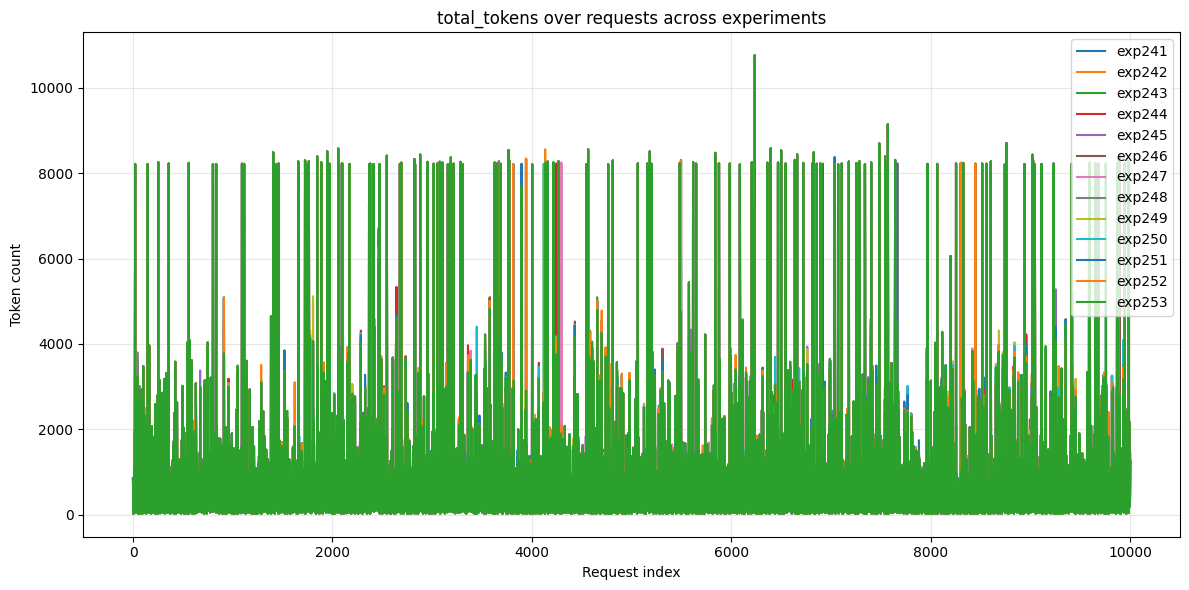

In [10]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt

# ---- choose experiments ----
# Option A: by series IDs
# series_ids = [53]
# experiments = experiments_from_series(series_ids)

# Option B: by start/end range
experiments = list(range(241, 254))

print(experiments)
# ----------------------------
# ---- choose ONE metric (uncomment exactly one) ----
# metric = "prompt_tokens"        # input length
# metric = "completion_tokens"  # output length
metric = "total_tokens"       # input + output
# -----------------------------------------------
plt.figure(figsize=(12, 6))
for exp_id in experiments:
    df = (
        load_experiment_latencies(exp_id=exp_id)
        .sort_values("idx")
        .reset_index(drop=True)
    )
    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue
    x = df["idx"]
    y = df[metric]
    plt.plot(x, y, label=f"exp{exp_id}")
plt.xlabel("Request index")
plt.ylabel("Token count")
plt.title(f"{metric} over requests across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

[241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253]


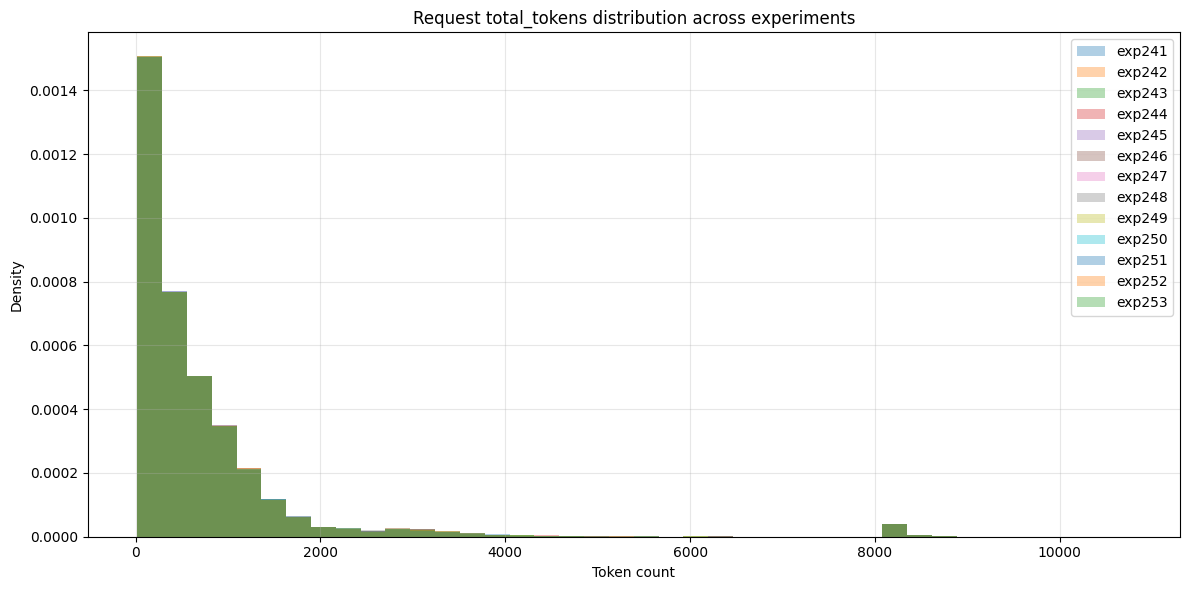

In [11]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
# Option A: by series IDs
# series_ids = [53]
# experiments = experiments_from_series(series_ids)

# Option B: by start/end range
experiments = list(range(241, 254))

print(experiments)
# ----------------------------
# ---- choose ONE metric (uncomment exactly one) ----
# metric = "prompt_tokens"        # input length distribution
# metric = "completion_tokens"  # output length distribution
metric = "total_tokens"       # input + output distribution
# -----------------------------------------------
plt.figure(figsize=(12, 6))
for exp_id in experiments:
    df = load_experiment_latencies(exp_id=exp_id)
    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue
    values = pd.to_numeric(df[metric], errors="coerce").dropna()
    if values.empty:
        print(f"Skipping exp{exp_id}: {metric} all NaN")
        continue
    plt.hist(
        values,
        bins=40,
        density=True,     # normalize so experiments are comparable
        alpha=0.35,
        label=f"exp{exp_id}",
    )
plt.xlabel("Token count")
plt.ylabel("Density")
plt.title(f"Request {metric} distribution across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

In [12]:
from pathlib import Path
from experiment_analysis import experiments_from_series
import json
import pandas as pd

# ---- choose experiments ----
# Option A: by series IDs
# series_ids = [53]
# experiments = experiments_from_series(series_ids)

# Option B: by start/end range
experiments = list(range(241, 254))

print(experiments)
# ----------------------------
def count_requests(exp_id, experiments_root="experiments"):
    exp_dir = Path(experiments_root) / str(exp_id)
    logs_path = exp_dir / "logs.json"
    if not logs_path.exists():
        raise FileNotFoundError(f"logs.json not found for experiment {exp_id}")
    total = 0
    success = 0
    send_failed = 0
    with logs_path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            rec = json.loads(line)
            total += 1
            if rec.get("send_failed", False):
                send_failed += 1
            else:
                success += 1
    return {
        "experiment": exp_id,
        "total_requests": total,
        "successful_requests": success,
        "connection_failed_requests": send_failed,
        "success_rate_pct": 100.0 * success / total if total > 0 else 0.0,
        "failure_rate_pct": 100.0 * send_failed / total if total > 0 else 0.0,
    }
rows = []
for exp_id in experiments:
    rows.append(count_requests(exp_id))
df_counts = pd.DataFrame(rows)
df_counts

[241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253]


,experiment,total_requests,successful_requests,connection_failed_requests,success_rate_pct,failure_rate_pct
0,241,10000,9998,2,99.98,0.02
1,242,10000,9998,2,99.98,0.02
2,243,10000,9998,2,99.98,0.02
3,244,10000,9997,3,99.97,0.03
4,245,10000,10000,0,100.00,0.00
5,246,10000,10000,0,100.00,0.00
6,247,10000,10000,0,100.00,0.00
7,248,10000,10000,0,100.00,0.00
8,249,10000,10000,0,100.00,0.00
9,250,10000,10000,0,100.00,0.00


In [13]:
from experiment_analysis import load_experiment_prom_samples, experiments_from_series
import pandas as pd

# -------- choose experiments to compare --------
# Option A: by series IDs
# series_ids = [53]
# experiments = experiments_from_series(series_ids)

# Option B: by start/end range
experiments = list(range(241, 254))

print(experiments)
# ----------------------------------------------
percentiles = [0.5, 0.9, 0.99]
# ============================================================
# METRICS ONLY (the ones we added ourselves)
# Choose ONE:
#   "router_only"   -> only router metrics (from :8080 rows)
#   "sidecar_only"  -> only sidecar metrics (from :8200 rows)
#   "all_new"       -> both router + sidecar (two views, same table)
# ============================================================
METRICS_MODE = "all_new"  # <- change me
ROUTER_COLS = [
    "router_queue_length",
    "router_admission_rps",
    "router_outgoing_rps",
]
SIDECAR_COLS = [
    "sidecar_queue_length",
    "sidecar_received_rps",
    "sidecar_completed_rps",
]
MODE_TO_COLS = {
    "router_only": ROUTER_COLS,
    "sidecar_only": SIDECAR_COLS,
    "all_new": ROUTER_COLS + SIDECAR_COLS,
}
if METRICS_MODE not in MODE_TO_COLS:
    raise ValueError(f"Unknown METRICS_MODE={METRICS_MODE!r}. Choose one of: {sorted(MODE_TO_COLS)}")
SELECT_COLS = MODE_TO_COLS[METRICS_MODE]
def _port_of_instance(inst: str):
    try:
        _, port = str(inst).rsplit(":", 1)
        return int(port)
    except Exception:
        return None
def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()
def _summarize_raw_cluster(df: pd.DataFrame, cols: list[str], exp_id: int) -> pd.DataFrame | None:
    """
    Cluster-view: aggregate across instances per tick, then describe across time.
    (No "coverage" output; just raw stats.)
    """
    if df.empty:
        return None
    cols = [c for c in cols if c in df.columns]
    if not cols:
        return None
    # per-tick aggregate across instances
    agg = df.groupby("ts")[cols].sum(min_count=1)
    # drop ticks where everything is missing (prevents NaN-only describe rows)
    agg = agg.dropna(how="all", subset=cols)
    if agg.empty:
        return None
    # if a metric is missing at some ticks, treat as 0 (keeps describe() clean)
    agg[cols] = agg[cols].fillna(0.0)
    # IMPORTANT: prefix ONLY with exp id (no redundant "sidecar_sidecar_*")
    return agg[cols].describe(percentiles=percentiles).add_prefix(f"exp{exp_id}_")
summaries = []
for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)
    if prom.empty:
        print(f"[WARN] exp{exp_id}: no prom metrics found (metrics.jsonl missing/empty)")
        continue
    router_df = _subset_by_port(prom, 8080)
    vllm_df = _subset_by_port(prom, 8200)
    if METRICS_MODE == "router_only":
        s = _summarize_raw_cluster(router_df, ROUTER_COLS, exp_id)
        if s is None:
            print(f"[WARN] exp{exp_id}: no router (:8080) samples found")
        else:
            summaries.append(s)
    elif METRICS_MODE == "sidecar_only":
        s = _summarize_raw_cluster(vllm_df, SIDECAR_COLS, exp_id)
        if s is None:
            print(f"[WARN] exp{exp_id}: no vLLM (:8200) samples found for sidecar_*")
        else:
            summaries.append(s)
    else:  # all_new
        # Router metrics should come from router rows (:8080)
        s_router = _summarize_raw_cluster(router_df, ROUTER_COLS, exp_id)
        if s_router is None:
            print(f"[WARN] exp{exp_id}: no router (:8080) samples found")
        else:
            summaries.append(s_router)
        # Sidecar metrics should come from vLLM rows (:8200) (where we mapped them)
        s_sidecar = _summarize_raw_cluster(vllm_df, SIDECAR_COLS, exp_id)
        if s_sidecar is None:
            print(f"[WARN] exp{exp_id}: no vLLM (:8200) samples found for sidecar_*")
        else:
            summaries.append(s_sidecar)
comparison = pd.concat(summaries, axis=1) if summaries else pd.DataFrame()
comparison

[241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253]
[WARN] exp245: no router (:8080) samples found
[WARN] exp245: no vLLM (:8200) samples found for sidecar_*
[WARN] exp246: no router (:8080) samples found
[WARN] exp246: no vLLM (:8200) samples found for sidecar_*
[WARN] exp247: no router (:8080) samples found
[WARN] exp247: no vLLM (:8200) samples found for sidecar_*
[WARN] exp248: no router (:8080) samples found
[WARN] exp248: no vLLM (:8200) samples found for sidecar_*
[WARN] exp249: no router (:8080) samples found
[WARN] exp249: no vLLM (:8200) samples found for sidecar_*
[WARN] exp250: no router (:8080) samples found
[WARN] exp250: no vLLM (:8200) samples found for sidecar_*
[WARN] exp251: no router (:8080) samples found
[WARN] exp251: no vLLM (:8200) samples found for sidecar_*
[WARN] exp252: no router (:8080) samples found
[WARN] exp252: no vLLM (:8200) samples found for sidecar_*
[WARN] exp253: no router (:8080) samples found
[WARN] exp253: no vLLM (:8200) samples 

,exp241_router_queue_length,exp241_router_admission_rps,exp241_router_outgoing_rps,exp241_sidecar_queue_length,exp241_sidecar_received_rps,exp241_sidecar_completed_rps,exp242_router_queue_length,exp242_router_admission_rps,exp242_router_outgoing_rps,exp242_sidecar_queue_length,...,exp243_router_outgoing_rps,exp243_sidecar_queue_length,exp243_sidecar_received_rps,exp243_sidecar_completed_rps,exp244_router_queue_length,exp244_router_admission_rps,exp244_router_outgoing_rps,exp244_sidecar_queue_length,exp244_sidecar_received_rps,exp244_sidecar_completed_rps
count,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,499.0,499.000000,499.000000,499.000000,...,489.000000,489.000000,489.000000,489.000000,482.0,482.000000,482.000000,482.000000,482.000000,482.000000
mean,7.830735,4.491018,0.310262,107.345212,4.484290,4.482133,0.0,4.049232,0.252746,344.553106,...,0.259507,235.394683,4.118968,4.123098,0.0,4.187687,0.261309,289.796680,4.184493,4.181378
std,18.759946,1.475822,0.145650,33.640746,1.508450,1.460436,0.0,1.938050,0.121635,190.438183,...,0.145996,108.361425,1.879655,1.591102,0.0,1.817512,0.114001,144.737026,1.822163,1.506722
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,5.000000,0.310345,119.000000,4.999918,4.896539,0.0,5.000000,0.310345,381.000000,...,0.275862,267.000000,4.999910,4.704455,0.0,5.000000,0.310345,362.000000,4.999947,4.689630
90%,30.200000,5.000000,0.482759,128.000000,5.241273,5.482801,0.0,5.000000,0.310345,569.000000,...,0.413793,368.200000,5.054118,5.344828,0.0,5.000000,0.310345,439.000000,5.034516,5.342197
99%,76.000000,5.001552,0.586207,128.000000,5.879997,5.896564,0.0,5.034483,0.344828,591.160000,...,0.551724,393.240000,5.103451,5.667642,0.0,5.034483,0.344828,461.380000,5.075578,5.799781
max,82.000000,5.034483,0.655172,128.000000,6.275883,6.310366,0.0,5.035714,0.344851,611.000000,...,0.586207,408.000000,5.113258,6.034461,0.0,5.068966,0.344875,471.000000,5.103620,6.137931


[241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253]
Skipping exp245: no rows for view='router'
Skipping exp246: no rows for view='router'
Skipping exp247: no rows for view='router'
Skipping exp248: no rows for view='router'
Skipping exp249: no rows for view='router'
Skipping exp250: no rows for view='router'
Skipping exp251: no rows for view='router'
Skipping exp252: no rows for view='router'
Skipping exp253: no rows for view='router'


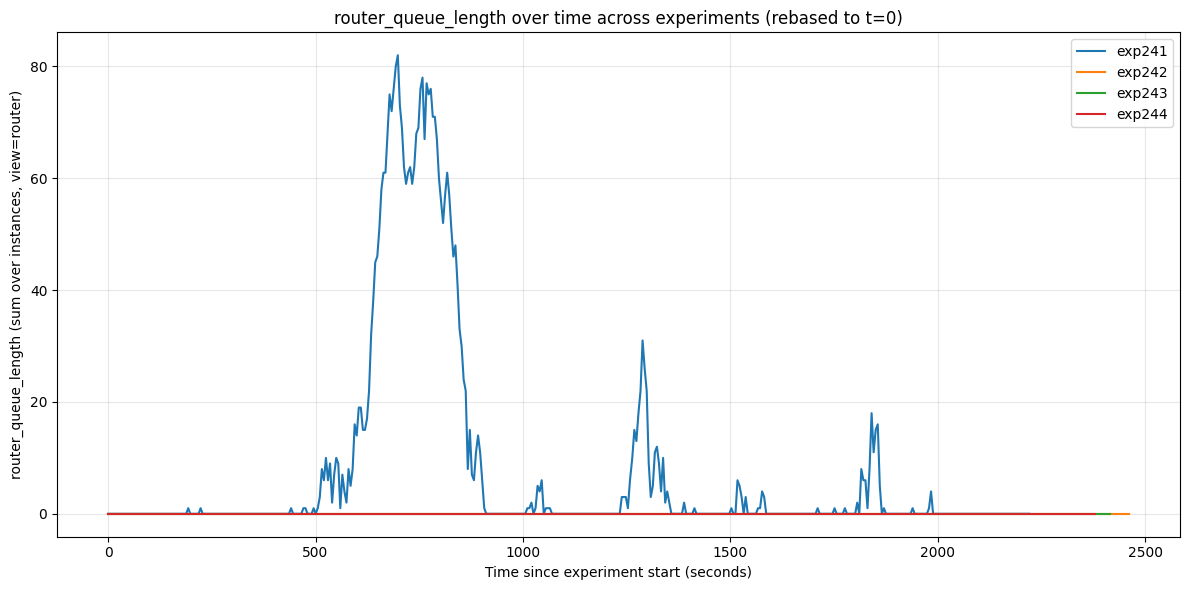

In [14]:
from experiment_analysis import load_experiment_prom_samples, experiments_from_series
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
# Option A: by series IDs
# series_ids = [53]
# experiments = experiments_from_series(series_ids)

# Option B: by start/end range
experiments = list(range(241, 254))

print(experiments)
# ----------------------------
# ============================================================
# METRICS ONLY (router + sidecar)
# Choose ONE metric (uncomment exactly one)
# ============================================================
# --- Router metrics ---
metric = "router_queue_length"
# metric = "router_admission_rps"
# metric = "router_outgoing_rps"
# --- Sidecar metrics ---
# metric = "sidecar_queue_length"
# metric = "sidecar_received_rps"
# metric = "sidecar_completed_rps"
# ============================================================
# Which "view" to plot?
#   - "router" : use :8080 rows (ground truth router pod)
#   - "vllm"   : use :8200 rows (broadcast router_* + mapped sidecar_*)
#
# Recommended:
#   - router_* -> view="router"
#   - sidecar_*-> view="vllm"
# ============================================================
view = "router"   # "router" or "vllm"
# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"    # "sum" (cluster-level) or "mean" (per-instance average)
# ---------------------------------------------------------
def _port_of_instance(inst: str):
    try:
        _, port = str(inst).rsplit(":", 1)
        return int(port)
    except Exception:
        return None
def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()
# Auto-pick a sensible default view if user forgets
if view not in ("router", "vllm"):
    raise ValueError("view must be 'router' or 'vllm'")
if metric.startswith("sidecar_") and view == "router":
    print("[WARN] sidecar_* metrics live on vLLM (:8200) rows. Switching view -> 'vllm'.")
    view = "vllm"
if metric.startswith("router_") and view == "vllm":
    print("[NOTE] plotting router_* from vLLM (:8200) rows uses the broadcast values.")
    print("       If you want router ground-truth, set view='router'.")
plt.figure(figsize=(12, 6))
for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)
    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue
    prom = prom.sort_values("ts").reset_index(drop=True)
    # Pick the right rows
    if view == "router":
        df = _subset_by_port(prom, 8080)
    else:
        df = _subset_by_port(prom, 8200)
    if df.empty:
        print(f"Skipping exp{exp_id}: no rows for view={view!r}")
        continue
    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found in view={view!r}")
        continue
    # Rebase time: each experiment starts at t=0 within this view
    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()
    # Aggregate across instances per tick (NaNs ignored; if all NaN at tick -> NaN)
    if agg_mode == "sum":
        series = df.groupby("t_rel_s")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances, view={view})"
    elif agg_mode == "mean":
        series = df.groupby("t_rel_s")[metric].mean()
        y_label = f"{metric} (mean over instances, view={view})"
    else:
        raise ValueError("agg_mode must be 'sum' or 'mean'")
    x = series.index
    y = series.values
    plt.plot(x, y, label=f"exp{exp_id}")
plt.xlabel("Time since experiment start (seconds)")
plt.ylabel(y_label)
plt.title(f"{metric} over time across experiments (rebased to t=0)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

[241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253]


/tmp/ipykernel_2071295/581597211.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(canonical_slots))


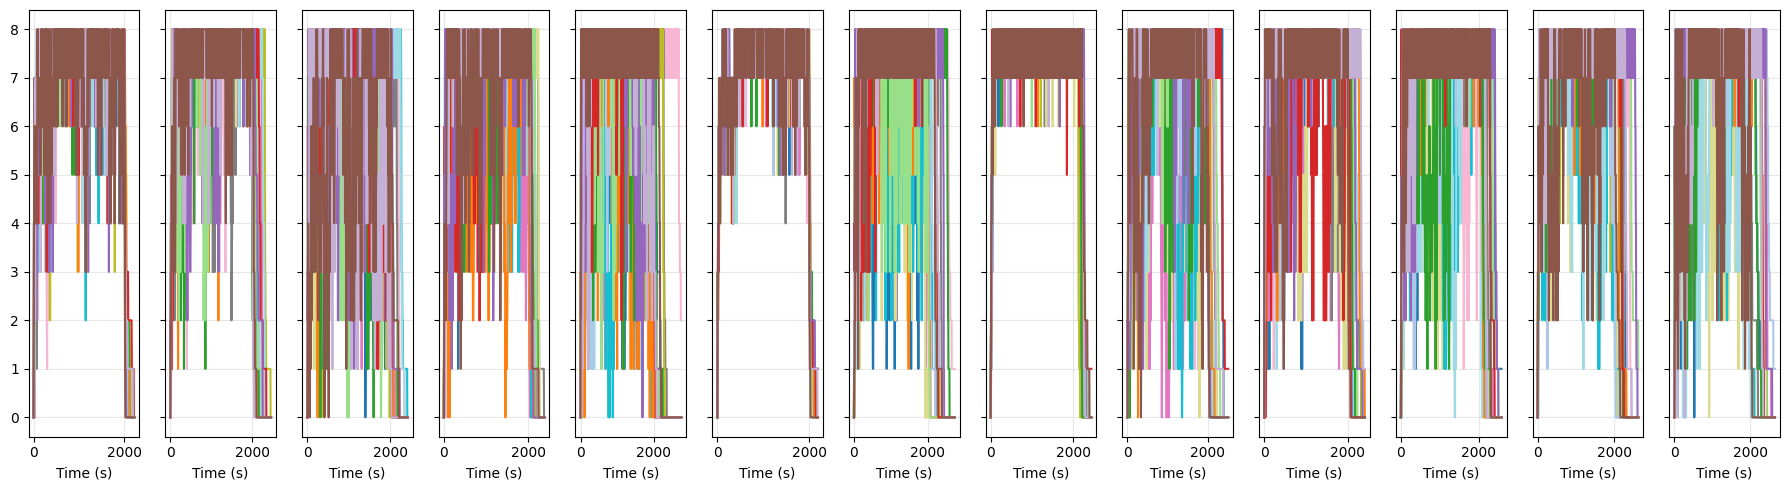

In [15]:
from experiment_analysis import load_experiment_prom_samples, experiments_from_series
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import re
import os

# ---- choose experiments ----
# Option A: by series IDs
# series_ids = [53]
# experiments = experiments_from_series(series_ids)

# Option B: by start/end range
experiments = list(range(241, 254))

print(experiments)
# ============================================================
# Choose ONE metric
# ============================================================
# metric = "sidecar_queue_length"
metric = "requests_running"
view = "vllm"  # sidecar_* live on vLLM (:8200)
def _port_of_instance(inst: str):
    try:
        _, port = str(inst).rsplit(":", 1)
        return int(port)
    except Exception:
        return None
def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()
def _natural_key(s: str):
    parts = re.split(r"(\d+)", str(s))
    return [int(p) if p.isdigit() else p for p in parts]
# ------------------------------------------------------------
# FIRST PASS: load data + assign server1..serverN per experiment
# ------------------------------------------------------------
data_by_exp = {}
max_servers = 0
for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)
    if prom.empty:
        continue
    prom = prom.sort_values("ts").reset_index(drop=True)
    df = _subset_by_port(prom, 8200)
    if df.empty or metric not in df.columns:
        continue
    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()
    insts = sorted(df["instance"].dropna().unique().tolist(), key=_natural_key)
    slot_map = {inst: f"server{i+1}" for i, inst in enumerate(insts)}
    df = df.copy()
    df["server_slot"] = df["instance"].map(slot_map)
    data_by_exp[exp_id] = df
    max_servers = max(max_servers, len(insts))
# Canonical slot names
canonical_slots = [f"server{i}" for i in range(1, max_servers + 1)]
# ------------------------------------------------------------
# Consistent colors per slot
# ------------------------------------------------------------
cmap = cm.get_cmap("tab20", len(canonical_slots))
color_map = {slot: cmap(i) for i, slot in enumerate(canonical_slots)}
# ------------------------------------------------------------
# Plot panels
# ------------------------------------------------------------
fig, axes = plt.subplots(1, len(experiments), figsize=(18, 5), sharey=True)
if len(experiments) == 1:
    axes = [axes]
for ax, exp_id in zip(axes, experiments):
    df = data_by_exp.get(exp_id)
    if df is None or df.empty:
        ax.grid(True, alpha=0.3)
        continue
    for slot, g in df.groupby("server_slot"):
        if slot not in color_map:
            continue
        g = g.sort_values("t_rel_s")
        ax.plot(
            g["t_rel_s"],
            g[metric],
            color=color_map[slot],
            linewidth=1.5,
        )
    ax.set_xlabel("Time (s)")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------
os.makedirs("figures", exist_ok=True)
plt.savefig(f"figures/{metric}_per_vllm_queue_comparison.png", dpi=300)
plt.show()